# 20260628

In [2]:
import sys
from pathlib import Path
import gzip

import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print(f"Python      : {sys.version.split()[0]}")
print(f"Platform    : {platform.platform()}")

print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"Matplotlib  : {plt.matplotlib.__version__}")

Python      : 3.11.15
Platform    : Linux-6.18.7-76061807-generic-x86_64-with-glibc2.39
NumPy       : 2.4.6
Pandas      : 3.0.3
Matplotlib  : 3.10.9


# Expected read would be

In [3]:
mrna_fasta = Path("../data/at1pct-mRNA.fa.gz")

mrna_ids = []
mrna_lengths = []

current_id = None
current_seq = []

with gzip.open(mrna_fasta, "rt") as f:
    for line in f:
        line = line.strip()

        if line.startswith(">"):
            if current_id is not None:
                mrna_ids.append(current_id)
                mrna_lengths.append(len("".join(current_seq)))

            current_id = line[1:].split()[0]
            current_seq = []
        else:
            current_seq.append(line)

if current_id is not None:
    mrna_ids.append(current_id)
    mrna_lengths.append(len("".join(current_seq)))

mrna_df = pd.DataFrame({
    "mrna_id": mrna_ids,
    "mrna_length": mrna_lengths,
})
print(mrna_df.shape)
display(mrna_df.head())

(428, 2)


,mrna_id,mrna_length
0,AT1G01010.1,2269
1,AT1G01020.1,2810
2,AT1G01020.2,1948
3,AT1G01030.1,2066
4,AT1G01040.1,8082


In [4]:
mrna_stats = pd.Series({
    "n_mRNAs": len(mrna_df),
    "mean_mRNA_length": mrna_df["mrna_length"].mean(),
    "stdev_mRNA_length": mrna_df["mrna_length"].std(),
    "median_mRNA_length": mrna_df["mrna_length"].median(),
    "min_mRNA_length": mrna_df["mrna_length"].min(),
    "max_mRNA_length": mrna_df["mrna_length"].max(),
})

mrna_stats.to_frame(name="Value")

,Value
n_mRNAs,428.000000
mean_mRNA_length,2224.815421
stdev_mRNA_length,1477.792797
median_mRNA_length,1970.000000
min_mRNA_length,96.000000
max_mRNA_length,9511.000000


In [5]:
lengths_sorted = sorted(mrna_df["mrna_length"], reverse=True)

total_bases = sum(lengths_sorted)
half_total_bases = total_bases / 2

running_total = 0
mrna_n50 = None

for length in lengths_sorted:
    running_total += length
    
    if running_total >= half_total_bases:
        mrna_n50 = length
        break

mrna_n50

2572

In [6]:
mrna_stats["N50_mRNA_length"] = mrna_n50
mrna_stats.to_frame(name="Value")

,Value
n_mRNAs,428.000000
mean_mRNA_length,2224.815421
stdev_mRNA_length,1477.792797
median_mRNA_length,1970.000000
min_mRNA_length,96.000000
max_mRNA_length,9511.000000
N50_mRNA_length,2572.000000


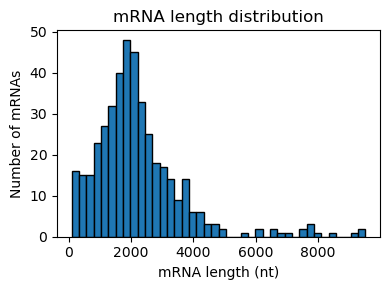

In [7]:
plt.figure(figsize=(4, 3))

plt.hist(mrna_df["mrna_length"], bins=40, edgecolor="black")

plt.xlabel("mRNA length (nt)")
plt.ylabel("Number of mRNAs")
plt.title("mRNA length distribution")

plt.tight_layout()
plt.show()

## FASTQ structure

A FASTQ file stores sequencing reads using four lines per record.

1. Read identifier
2. Nucleotide sequence
3. Separator (`+`)
4. Base quality scores

In [8]:
fastq = Path("../data/1k.fastq.gz")

with gzip.open(fastq, "rt") as f:
    for i in range(8):
        print(f.readline().rstrip())

@e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac runid=d0fb633a8fcd5fbe39934e46437aa38eed37012a ch=2942 start_time=2024-12-10T06:05:47.830848+09:00 flow_cell_id=PBA40360 protocol_group_id=241209-GEBY-1s_AP-P4BBp1439 sample_id=NA03164 barcode=barcode14 barcode_alias=barcode14 parent_read_id=e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac basecall_model_version_id=dna_r10.4.1_e8.2_400bps_hac@v4.3.0
GCTGTTTATGTCATTATTTACTTCGTTCAGTTATGCAGCCAATCCGCAAACTCGCCTACCGTGACAACGAGTCTCTTGGGACCCATAGAACTTGCCTGTCGCTCTCTTCAGAGGAGAATTCCGCCGCCCACAGGTCTTTTTTTTTTTTTTTTTTTTTTAACTAAAAAGGTTTTATTTTATTGAATCATATTTCATTAACGCCACATTACACTCACAAGAACAACGAGAATACAAACAATACAGGCAAGTCTCACGAATCACAACACATCACTTAAACGACCCAAAAAGTTTTTGCAATTTCAGACCCGACCCGACTAACACTATCCCTAAGCTTGACCGGACAATTGTTGATTATCTAGGCGGTGAGCTCATAAGGAGAAGTATCAGTAGCGAGCCATTGCTCCCCAAAACTCCAAGTCCAAGTCTAATTCCAAAGCAATATGAGCACGACGGGATGCGTACCGAGTTGGTG
+
'''(+)&%&'('&&&$$%$$$%''()*.))()'('&$##$##$$$#####%$$%*)((152><<</...2//27564/21333837%%%&$%%%,-,7:74567<,(((*()(*120+**()(+*(*++**'%$%%(*-*,.05667

In [9]:
with gzip.open(fastq, "rt") as f:
    header = f.readline().strip()
    sequence = f.readline().strip()
    plus = f.readline().strip()
    quality = f.readline().strip()

print("Header:")
print(header)

print("\nSequence first 80 nt:")
print(sequence[:80])

print("\nPlus line:")
print(plus)

print("\nQuality first 80 characters:")
print(quality[:80])

print("\nSequence length:", len(sequence))
print("Quality length :", len(quality))

Header:
@e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac runid=d0fb633a8fcd5fbe39934e46437aa38eed37012a ch=2942 start_time=2024-12-10T06:05:47.830848+09:00 flow_cell_id=PBA40360 protocol_group_id=241209-GEBY-1s_AP-P4BBp1439 sample_id=NA03164 barcode=barcode14 barcode_alias=barcode14 parent_read_id=e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac basecall_model_version_id=dna_r10.4.1_e8.2_400bps_hac@v4.3.0

Sequence first 80 nt:
GCTGTTTATGTCATTATTTACTTCGTTCAGTTATGCAGCCAATCCGCAAACTCGCCTACCGTGACAACGAGTCTCTTGGG

Plus line:
+

Quality first 80 characters:
'''(+)&%&'('&&&$$%$$$%''()*.))()'('&$##$##$$$#####%$$%*)((152><<</...2//27564/21

Sequence length: 472
Quality length : 472


In [10]:
read_ids = []
lengths = []

with gzip.open(fastq, "rt") as f:
    while True:
        header = f.readline().strip()
        sequence = f.readline().strip()
        plus = f.readline().strip()
        quality = f.readline().strip()

        if not header:
            break

        assert header.startswith("@")
        assert plus == "+"
        assert len(sequence) == len(quality)

        read_ids.append(header[1:].split()[0])
        lengths.append(len(sequence))

df = pd.DataFrame({
    "read_id": read_ids,
    "length": lengths
})

print(df.shape)
display(df.head())

(1000, 2)


,read_id,length
0,e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac,472
1,976d29dc-8666-41fe-9fdf-8ec7dbd57ee9,529
2,e61fdbfd-bcb3-4c9b-b34b-8e9f6c952c58,471
3,b066f69a-4698-4898-ad43-e1ecb2b4b5ab,489
4,49fa6fba-28a3-4889-b324-880e6e80b971,368


In [11]:
lengths_sorted = sorted(df["length"], reverse=True)

total_bases = sum(lengths_sorted)
half_total_bases = total_bases / 2

running_total = 0
n50 = None

for length in lengths_sorted:
    running_total += length
    
    if running_total >= half_total_bases:
        n50 = length
        break

n50

598

In [12]:
stats = pd.Series({
    "n_reads": len(df),
    "mean_length": df["length"].mean(),
    "stdev_length": df["length"].std(),
    "median_length": df["length"].median(),
    "n50": n50,
    "min_length": df["length"].min(),
    "max_length": df["length"].max(),
})

stats
stats.to_frame(name="Value")

,Value
n_reads,1000.000000
mean_length,600.506000
stdev_length,201.088101
median_length,550.000000
n50,598.000000
min_length,262.000000
max_length,2131.000000


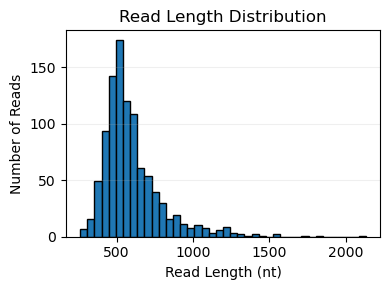

In [13]:
plt.figure(figsize=(4, 3))

plt.hist(df["length"], bins=40, edgecolor="black")

plt.title("Read Length Distribution")
plt.xlabel("Read Length (nt)")
plt.ylabel("Number of Reads")

plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

## SO WHAT?

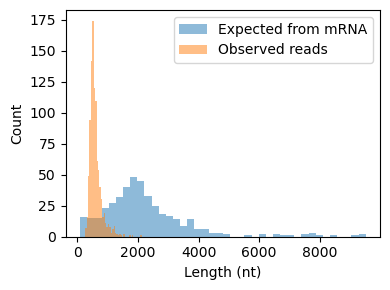

In [16]:
plt.figure(figsize=(4, 3))

plt.hist(
    mrna_df["mrna_length"],
    bins=40,
    alpha=0.5,
    label="Expected from mRNA"
)

plt.hist(
    df["length"],
    bins=40,
    alpha=0.5,
    label="Observed reads"
)

plt.xlabel("Length (nt)")
plt.ylabel("Count")
plt.legend()

plt.tight_layout()
plt.show()

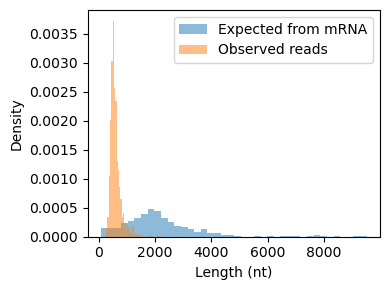

In [17]:
plt.figure(figsize=(4, 3))

plt.hist(
    mrna_df["mrna_length"],
    bins=40,
    density=True,
    alpha=0.5,
    label="Expected from mRNA"
)

plt.hist(
    df["length"],
    bins=40,
    density=True,
    alpha=0.5,
    label="Observed reads"
)

plt.xlabel("Length (nt)")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()